In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d
import seaborn as sns

In [2]:
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\PI_FP_IMU\\RUN_03.csv', sep = ',', header = [3], low_memory = False)
ff = df.iloc[df[df['Frame']=='Frame'].index[0]+2:, :]
ff.columns = df.iloc[df[df['Frame']=='Frame'].index[0],:].values.tolist()
force_df = ff[['Frame', 'Sub Frame', 'Fx','Fy','Fz','Mx','My','Mz','Cx','Cy','Cz']].astype('float')
imu_down = df.iloc[1:df[df['Frame']=='Devices'].index[0], :].astype('float')

In [8]:
acc = imu_down.iloc[:,2:5]/1000

In [51]:
gyro = imu_down.iloc[:,50:53]

<AxesSubplot:>

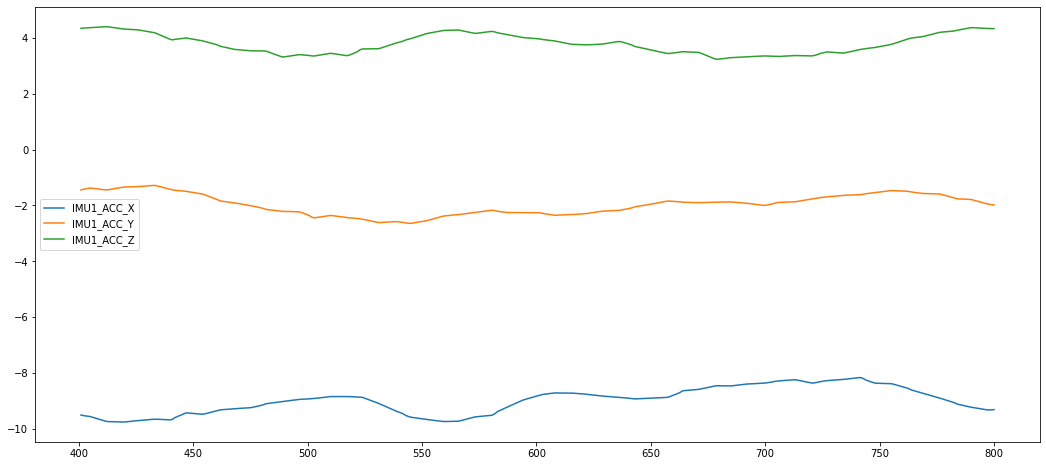

In [44]:
#gyr[9000:9380].plot(figsize=[18,8])
acc[400:800].plot(figsize=[18,8])

,IMU1_ACC_X,IMU1_ACC_Y,IMU1_ACC_Z
401,-9.50976,-1.44741,4.34746
402,-9.52909,-1.42013,4.35542
403,-9.54015,-1.40452,4.35998
404,-9.55120,-1.38891,4.36453
405,-9.56355,-1.37571,4.36914
...,...,...,...
796,-9.31206,-1.92236,4.34631
797,-9.32572,-1.94512,4.34176
798,-9.32781,-1.96095,4.33914
799,-9.32196,-1.97200,4.33784


In [61]:
yAxisSen = getyAxis(acc[400:800].values)
zAxisSen = getzAxis(gyro[9000:9380].values, 1)
yAxisSeg = np.array([[0], [1], [0]])
zAxisSeg = np.array([[0], [0], [1]])
R = wahba(yAxisSen, zAxisSen, yAxisSeg, zAxisSeg)
acc_rot = acc.values @ R.T
gyr_rot = gyro.values @ R.T

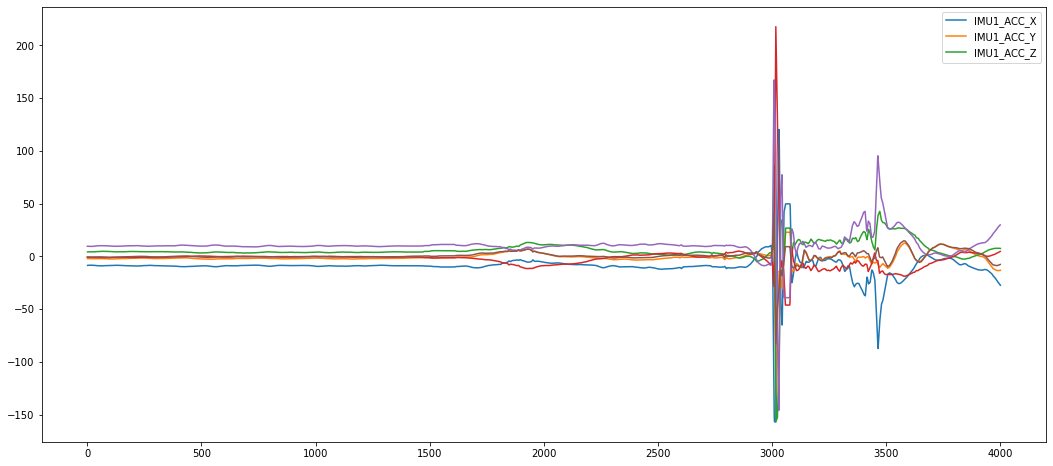

In [76]:
acc.iloc[:4000,:].plot(figsize=[18,8])
plt.plot(acc_rot[:4000])

In [ ]:
yAxisSen = getyAxis(acc[400:800])


    # Get z axis in sensor coordinate system
    direction = 1  # 1: counter-clockwise movement; -1: clockwise movement
    

    # Estimate rotation matrix to segment coordinate system using the SVD solution of Wahba’s problem
    yAxisSeg = np.array([[0], [1], [0]])
    zAxisSeg = np.array([[0], [0], [1]])
    R = wahba(yAxisSen, zAxisSen, yAxisSeg, zAxisSeg)


In [40]:
def getyAxis(acc):
    # Mean for each sensor axis
    accMean = np.mean(acc, axis=0)

    # Mean normalized by the Euclidean norm of the mean
    yAxis = accMean / np.linalg.norm(accMean)

    return yAxis.reshape(-1, 1)

In [41]:
def getzAxis(gyro, direction):
    # Use here the transposed version to have same notation as in matlab code
    gyro = np.transpose(gyro)

    # Mean for each sensor axis
    gyroMean = np.mean(gyro, axis=1)

    # Mean free signal for each sensor axis
    gyroMeanFree = gyro - gyroMean[:, None]

    # SVD
    u, _, _ = np.linalg.svd(gyroMeanFree)

    # First eigenvector is approximately parallel to the axis of rotation
    zAxis = u[:, 0]

    # Project all samples on zAxis to estimate total angle
    theta = np.sum(np.transpose(gyro) @ zAxis)

    # Correct sign of zAxis
    zAxis = zAxis * np.sign(theta) * np.sign(direction)

    return zAxis.reshape(-1, 1) 

In [45]:
def wahba(v1, v2, w1, w2):
    """This function implements Wahba's problem for n = 2 and a_i = 1.
    See https://en.wikipedia.org/wiki/Wahba%27s_problem
    """

    # Obtain matrix B
    B = w1 @ np.transpose(v1) + w2 @ np.transpose(v2)

    # Perform SVD
    U, S, V_transposed = np.linalg.svd(B)

    # Compute rotation
    M = np.diag([1, 1, np.linalg.det(U) * np.linalg.det(V_transposed)])
    R = U @ M @ V_transposed

    return R

In [ ]:
        # Apply rotation R^-1:
        # - Since acc and gyro are Nx3 and not 3xN, we would have to perform two transpose: B = (R * A^T)^T
        # - To perform less transpose, this can be reformulated as B = (R * A^T)^T = A * R^T
        R = rotations[dataset.info.sensor_position]
        R_trans = np.transpose(R)
        dataset.acc.data = dataset.acc.data @ R_trans
        dataset.gyro.data = dataset.gyro.data @ R_trans
